# Heart Disease Dataset Understanding

## Objective
Understand the structure, features, data types, and quality of the Heart Disease dataset before preprocessing and model training.

In [3]:
import pandas as pd
import numpy as np

from pathlib import Path
import sys

In [4]:
PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

In [5]:
from src.config import HEART_DATASET

In [6]:
df = pd.read_csv(HEART_DATASET)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,0.0,1.0,145.0,160.0,0.0,1.0,161.0,0.0,0.0,1.0,0.0,2.0,1.0
1,57.0,1.0,2.0,112.0,286.0,0.0,0.0,150.0,1.0,1.6,1.0,1.0,2.0,1.0
2,44.0,0.0,0.0,150.0,175.0,0.0,1.0,156.0,0.0,0.0,1.0,0.0,2.0,0.0
3,46.0,1.0,1.0,150.0,269.0,0.0,1.0,159.0,1.0,0.5,2.0,1.0,3.0,1.0
4,54.0,1.0,2.0,120.0,309.0,0.0,1.0,195.0,1.0,2.0,1.0,0.0,3.0,1.0


In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (3235, 14)


In [8]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3235 entries, 0 to 3234
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       3235 non-null   float64
 1   sex       3235 non-null   float64
 2   cp        3235 non-null   float64
 3   trestbps  3235 non-null   float64
 4   chol      3235 non-null   float64
 5   fbs       3235 non-null   float64
 6   restecg   3235 non-null   float64
 7   thalach   3235 non-null   float64
 8   exang     3235 non-null   float64
 9   oldpeak   3235 non-null   float64
 10  slope     3235 non-null   float64
 11  ca        3235 non-null   float64
 12  thal      3235 non-null   float64
 13  target    3235 non-null   float64
dtypes: float64(14)
memory usage: 354.0 KB


In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000
mean,54.533774,0.672302,0.937447,131.798502,246.302437,0.510055,0.522574,149.116613,0.440622,1.046243,1.395919,0.742440,2.298034,0.540649
std,8.976545,0.469404,1.026009,18.004546,52.531289,0.499919,0.521011,23.212151,0.496853,1.168006,0.611208,1.023453,0.607317,0.498422
min,28.661793,-0.024556,-0.071508,93.304637,123.758968,-0.028420,-0.033105,69.617540,-0.031838,-0.074034,-0.029055,-0.087065,-0.011382,0.000000
25%,47.829891,0.006625,0.000000,119.998705,210.473903,0.000000,0.000000,132.783423,-0.000396,0.012786,0.997654,-0.001424,1.994640,0.000000
50%,55.868154,0.994835,0.973762,129.982563,240.879546,0.980413,0.979625,152.337157,0.012315,0.776862,1.015948,0.022733,2.007764,1.000000
75%,61.015992,1.002110,1.995305,140.141569,275.048038,1.000000,1.000000,165.798135,0.999695,1.772279,1.999247,1.016615,2.995372,1.000000
max,77.252090,1.032402,3.069119,200.544513,565.208396,1.032028,2.023007,202.707794,1.028932,6.228175,2.036469,4.038031,3.038514,1.000000


In [11]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["target"].value_counts()

target
1.0    1749
0.0    1486
Name: count, dtype: int64

In [14]:
df["target"].value_counts(normalize=True) * 100

target
1.0    54.064915
0.0    45.935085
Name: proportion, dtype: float64

# Exploratory Data Analysis (EDA)

## 1. Target Variable Analysis

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("ggplot")

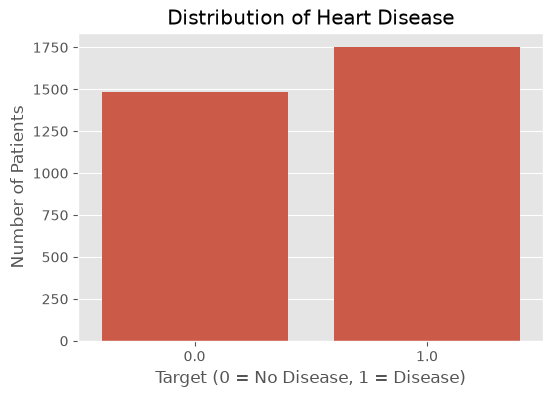

In [18]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="target")

plt.title("Distribution of Heart Disease")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Number of Patients")

plt.show()

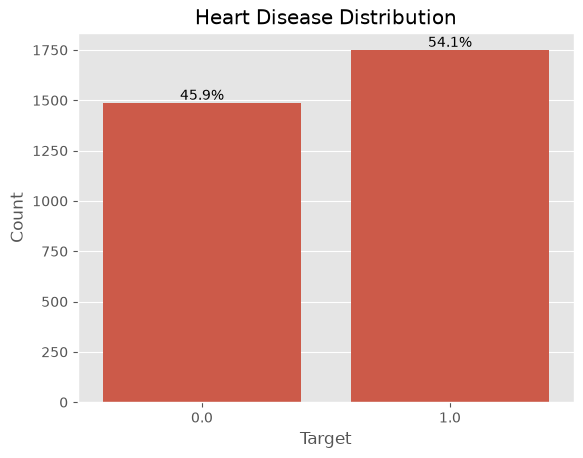

In [19]:
ax = sns.countplot(data=df, x="target")

total = len(df)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f"{percentage:.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center",
                va="bottom")

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

## 2. Numerical Feature Analysis

In [20]:
numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

numerical_columns

['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

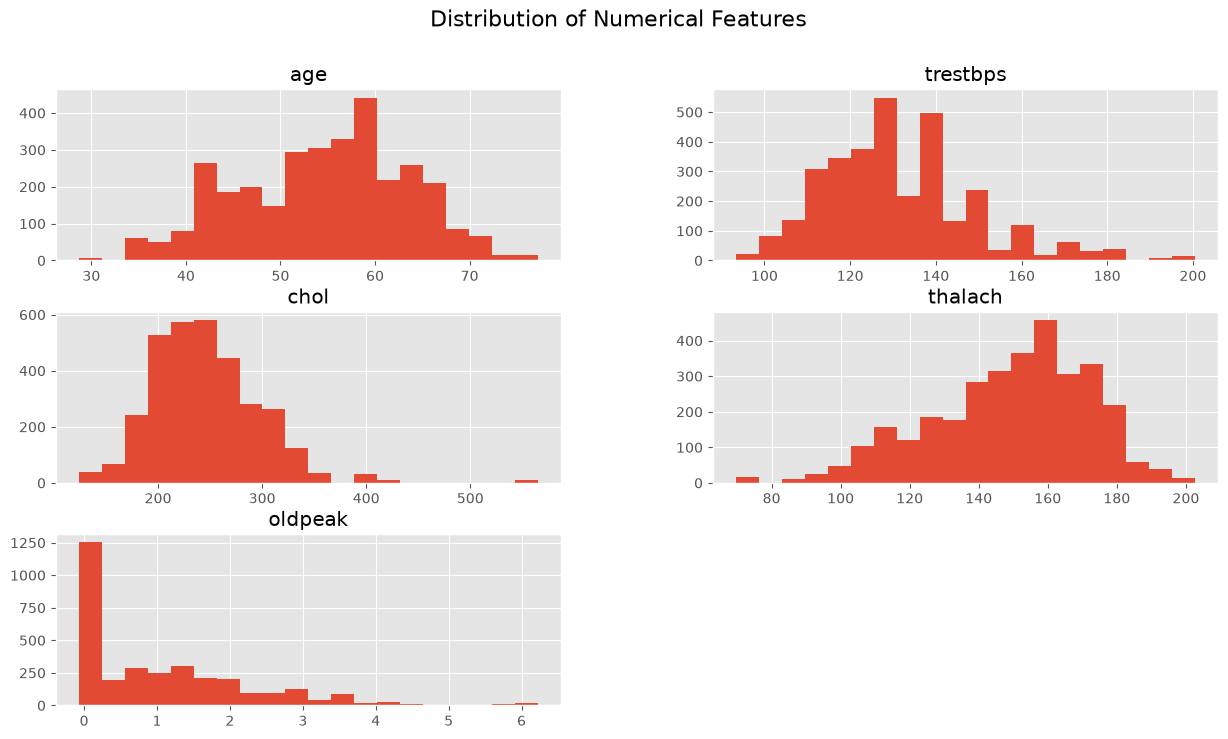

In [21]:
df[numerical_columns].hist(figsize=(15, 8), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.show()

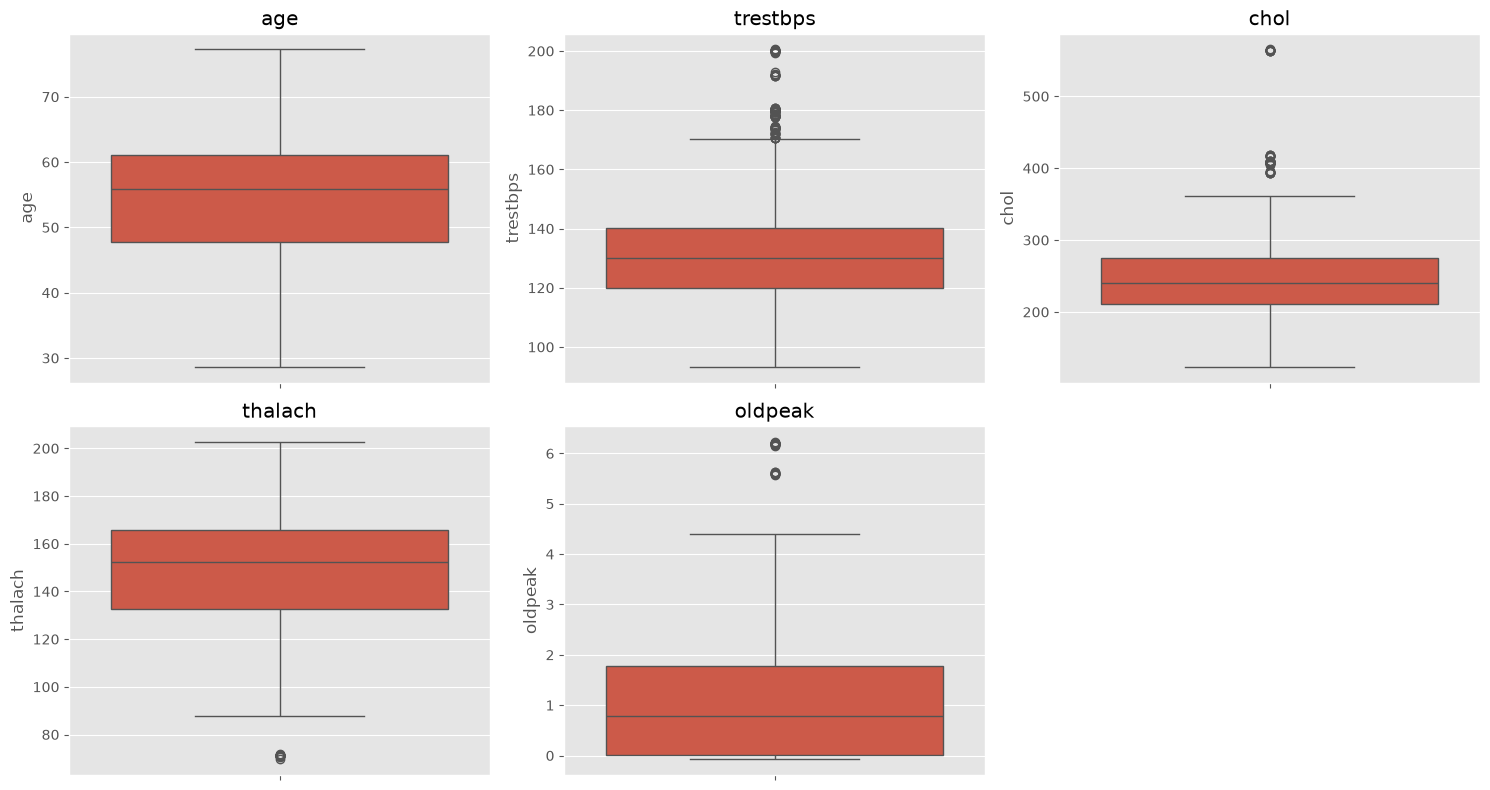

In [22]:
plt.figure(figsize=(15,8))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

### Observations

- Most patients belong to the age group of 45–65 years.
- Resting blood pressure values are mainly between 110–140 mmHg, with a few high outliers.
- Cholesterol is right-skewed and contains several outliers.
- Maximum heart rate is approximately normally distributed.
- Oldpeak is highly right-skewed and contains multiple outliers.

# 3. Correlation Analysis

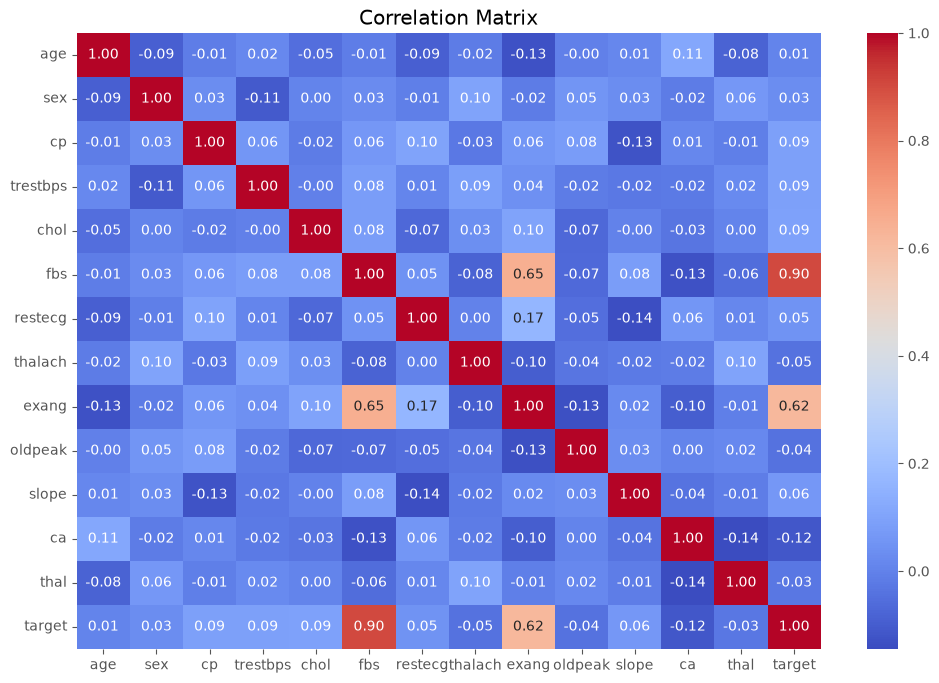

In [23]:
plt.figure(figsize=(12,8))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Observations

- The target variable shows the highest positive correlation with **fbs** and **exang**.
- Most other features have weak to moderate correlations with the target.
- No strong multicollinearity is observed among most numerical features.
- Correlation helps us understand feature relationships but does not imply causation.

## 4. Feature vs Target Analysis

### Age vs Target

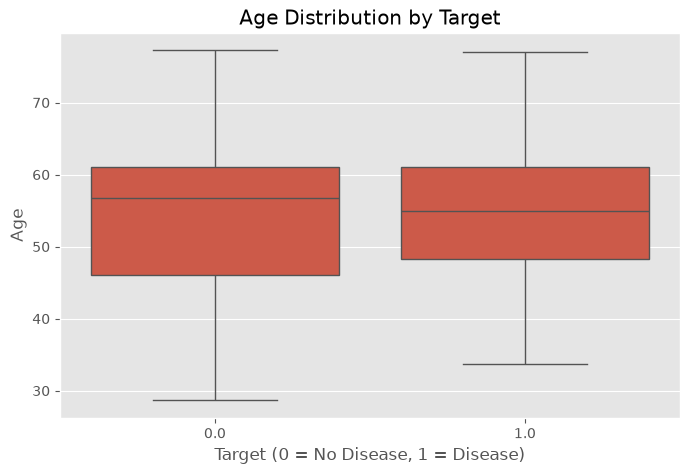

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="target", y="age")

plt.title("Age Distribution by Target")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Age")

plt.show()

### Observation

- Compare the age distribution of patients with and without heart disease.
- Check whether one group tends to have a higher median age.

### Cholesterol vs Target

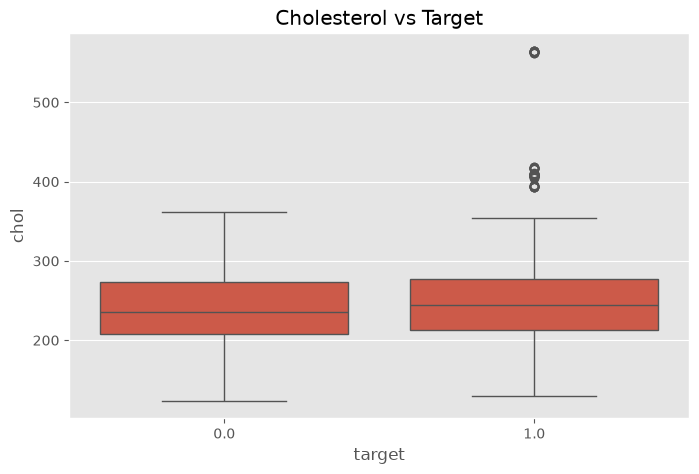

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="target", y="chol")

plt.title("Cholesterol vs Target")

plt.show()

### Observation

- Compare cholesterol levels between both target classes.
- Identify whether disease patients generally have higher cholesterol values.

### Resting Blood Pressure vs Target

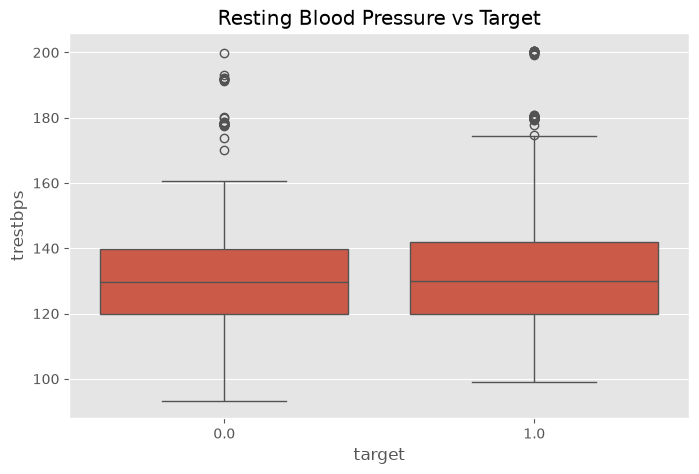

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="target", y="trestbps")

plt.title("Resting Blood Pressure vs Target")

plt.show()

### Maximum Heart Rate vs Target

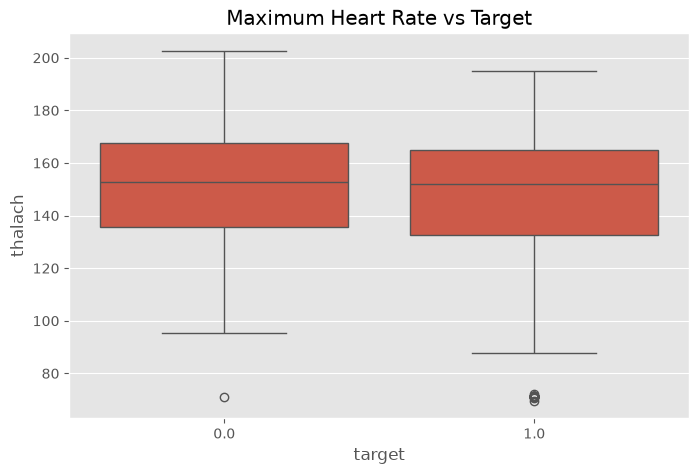

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="target", y="thalach")

plt.title("Maximum Heart Rate vs Target")

plt.show()

### Chest pain type

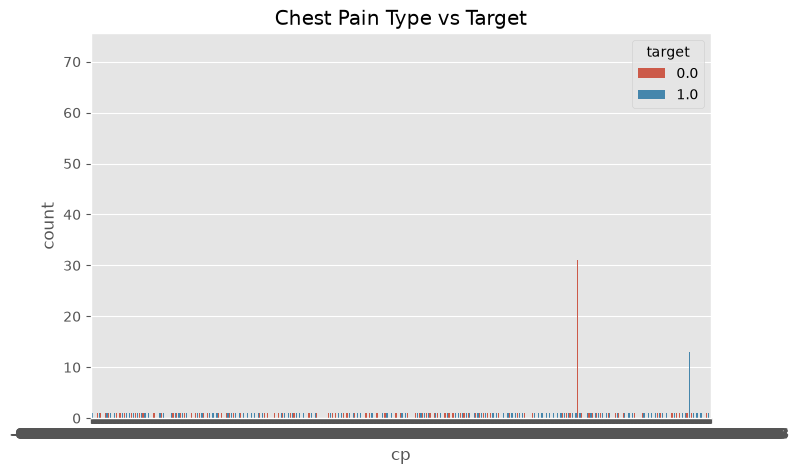

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="cp", hue="target")

plt.title("Chest Pain Type vs Target")

plt.show()

### Gender Distribution

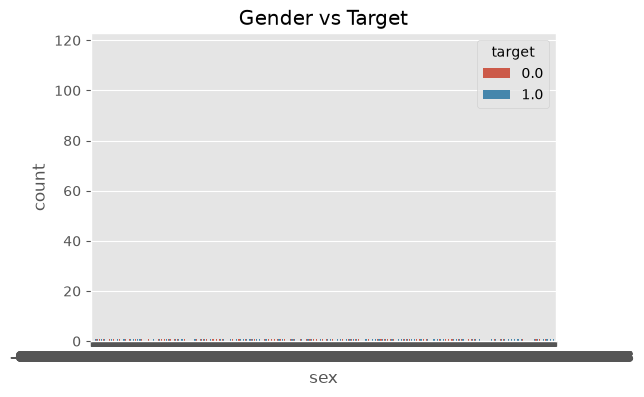

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="sex", hue="target")

plt.title("Gender vs Target")

plt.show()

### Correlation with Target Only

In [30]:
correlation = df.corr(numeric_only=True)["target"].sort_values(ascending=False)

print(correlation)

target      1.000000
fbs         0.903141
exang       0.618324
chol        0.093759
cp          0.092063
trestbps    0.091375
slope       0.061407
restecg     0.050080
sex         0.032496
age         0.005383
thal       -0.031759
oldpeak    -0.044124
thalach    -0.045857
ca         -0.117532
Name: target, dtype: float64


# EDA Summary

## Key Findings

- The dataset contains no missing values.
- No duplicate records were found.
- The target classes are reasonably balanced.
- Numerical features show different distributions.
- Some features contain outliers, which is common in medical datasets.
- Correlation analysis provides insights into feature relationships.
- Feature vs target plots help understand how medical attributes differ between patients with and without heart disease.

## Conclusion

- The dataset is clean and suitable for preprocessing and machine learning model development.